<a href="https://colab.research.google.com/github/pmlg/pytorch_GCN/blob/master/bfsi-fraud-suite-Notebook/notebooks/bfsi_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
  <h1>
    <img src="https://kumo-ai.github.io/kumo-sdk/docs/_static/kumo-logo.svg" style="height: 40px; vertical-align: bottom;"/>
    BFSI Fraud Detection: Merchant Collusion Rings
  </h1>
</div>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AbhinavKhareTech/kumo-rfm/blob/contrib/bfsi-fraud-suite-Notebook/notebooks/bfsi_fraud_detection.ipynb)

This notebook demonstrates how to use **KumoRFM** for **merchant payment fraud detection**, specifically targeting **collusion ring patterns** in multi-table transaction data.

**Why graph-based fraud detection matters:** Traditional fraud models treat each transaction independently, extracting features from a single row. But the hardest fraud patterns — collusion rings, mule networks, bust-out schemes — are inherently relational. They only become visible when you look at *how entities connect across tables*. A mule user transacting across five seemingly unrelated merchants is invisible to flat-feature models but structurally obvious in a graph.

KumoRFM's graph transformer architecture captures these cross-entity connectivity patterns natively, making it an ideal fit for relational fraud detection.

**What this notebook covers:**
1. Synthetic data generation with embedded fraud ring structures
2. Building a KumoRFM `LocalGraph` from multi-table payments data
3. PQL-based fraud scoring with temporal train/test split
4. Baseline comparison against XGBoost on hand-engineered flat features
5. Fraud ring subgraph visualization
6. Production deployment considerations

**Note:** The KumoRFM prediction cells (Sections 4–5) require a valid KumoRFM API key.

## 1. Setup and Installation

In [18]:
# Install required packages
!pip install -q kumoai xgboost networkx matplotlib seaborn scikit-learn pandas numpy

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datetime import datetime, timedelta

from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    f1_score
)
from xgboost import XGBClassifier
from kumoai.experimental import rfm

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

print("All imports successful.")

All imports successful.


In [21]:
import os
import kumoai.experimental.rfm as rfm
from google.colab import userdata

# Get API key from Colab secrets or environment variable
api_key = userdata.get("KUMO_API_KEY") or os.environ.get("KUMO_API_KEY")

if api_key:
    # Initialize KumoRFM with the API key
    rfm.init(api_key=api_key)
    print("KumoRFM initialized with API key.")
else:
    # If no key is found, fall back to interactive authentication
    print("KUMO_API_KEY not found. Performing interactive authentication...")
    rfm.authenticate()
    print("KumoRFM authenticated successfully.")

print("KumoRFM client is ready.")

RuntimeError: KumoRFM has already been initialized with a different API URL. Re-initialization with a different URL is not supported.

## 2. Data Generation: Multi-Table Payments Dataset with Fraud Rings

We generate a synthetic payments dataset with **three relational tables** and **embedded collusion ring structures**.

**Schema:**
- `merchants` — merchant profiles (merchant_id, category, registration_date, city)
- `users` — user/cardholder profiles (user_id, signup_date, city, device_type)
- `transactions` — payment events linking users to merchants (txn_id, user_id, merchant_id, amount, timestamp, channel, is_fraud)

**Fraud scenarios embedded in the data:**

| Pattern | Description | Signal Type |
|---------|-------------|-------------|
| **Collusion Ring** | 5-8 mule users shared across 2-3 merchants, coordinated bursts | Relational/structural |
| **Velocity Burst** | Single user with abnormally high transaction frequency | Single-entity temporal |
| **Amount Anomaly** | Transactions far outside normal distribution for category | Single-row feature |

The collusion ring pattern is the key test case. Flat-feature models can catch velocity bursts and amount anomalies, but collusion rings require understanding cross-entity graph structure.

In [22]:
np.random.seed(42)

# ---- Configuration ----
N_MERCHANTS = 200
N_USERS = 2000
N_TRANSACTIONS = 50000
N_FRAUD_RINGS = 8
RING_SIZE_USERS = (5, 8)
RING_SIZE_MERCHANTS = (2, 3)
FRAUD_RATE_RING = 0.85
BASE_DATE = datetime(2024, 1, 1)
END_DATE = datetime(2024, 12, 31)
TEMPORAL_CUTOFF = datetime(2024, 10, 1)  # Train/test split point

CATEGORIES = [
    "retail", "grocery", "electronics", "dining", "fuel",
    "travel", "healthcare", "entertainment", "utilities", "services"
]
CITIES = [
    "Mumbai", "Delhi", "Bangalore", "Hyderabad", "Chennai",
    "Pune", "Kolkata", "Ahmedabad", "Jaipur", "Lucknow"
]
CHANNELS = ["pos", "online", "mobile", "contactless"]
DEVICES = ["android", "ios", "web", "feature_phone"]

# ---- Generate Merchants ----
merchants_df = pd.DataFrame({
    "merchant_id": [f"M{i:04d}" for i in range(N_MERCHANTS)],
    "category": np.random.choice(CATEGORIES, N_MERCHANTS),
    "registration_date": [
        BASE_DATE - timedelta(days=int(np.random.uniform(30, 1000)))
        for _ in range(N_MERCHANTS)
    ],
    "city": np.random.choice(CITIES, N_MERCHANTS),
})

# ---- Generate Users ----
users_df = pd.DataFrame({
    "user_id": [f"U{i:04d}" for i in range(N_USERS)],
    "signup_date": [
        BASE_DATE - timedelta(days=int(np.random.uniform(1, 730)))
        for _ in range(N_USERS)
    ],
    "city": np.random.choice(CITIES, N_USERS),
    "device_type": np.random.choice(DEVICES, N_USERS),
})

print(f"Merchants: {len(merchants_df)}")
print(f"Users: {len(users_df)}")
print(f"\nMerchant categories: {merchants_df['category'].value_counts().to_dict()}")

Merchants: 200
Users: 2000

Merchant categories: {'healthcare': 26, 'entertainment': 23, 'retail': 23, 'utilities': 20, 'fuel': 20, 'electronics': 19, 'services': 19, 'dining': 18, 'grocery': 17, 'travel': 15}


In [23]:
# ---- Generate Transactions ----
# Step 1: Legitimate transactions
txn_records = []
for i in range(N_TRANSACTIONS):
    user_id = f"U{np.random.randint(0, N_USERS):04d}"
    merchant_id = f"M{np.random.randint(0, N_MERCHANTS):04d}"
    timestamp = BASE_DATE + timedelta(
        seconds=int(np.random.uniform(0, (END_DATE - BASE_DATE).total_seconds()))
    )
    amount = round(min(np.random.lognormal(mean=6.0, sigma=1.2), 50000), 2)
    channel = np.random.choice(CHANNELS, p=[0.3, 0.35, 0.25, 0.1])

    txn_records.append({
        "txn_id": f"T{i:06d}",
        "user_id": user_id,
        "merchant_id": merchant_id,
        "amount": amount,
        "timestamp": timestamp,
        "channel": channel,
        "is_fraud": 0,
    })

# Step 2: Inject collusion ring fraud
ring_txn_id = N_TRANSACTIONS
fraud_ring_info = []

for ring_idx in range(N_FRAUD_RINGS):
    n_ring_users = np.random.randint(*RING_SIZE_USERS)
    n_ring_merchants = np.random.randint(*RING_SIZE_MERCHANTS)

    ring_users = [f"U{np.random.randint(0, N_USERS):04d}" for _ in range(n_ring_users)]
    ring_merchants = [f"M{np.random.randint(0, N_MERCHANTS):04d}" for _ in range(n_ring_merchants)]

    ring_start = BASE_DATE + timedelta(
        days=int(np.random.uniform(30, (END_DATE - BASE_DATE).days - 30))
    )
    ring_duration_days = np.random.randint(3, 14)

    # Each mule user transacts with EACH ring merchant (the structural signal)
    for user_id in ring_users:
        for merchant_id in ring_merchants:
            n_txns = np.random.randint(3, 8)
            for _ in range(n_txns):
                timestamp = ring_start + timedelta(
                    seconds=int(np.random.uniform(0, ring_duration_days * 86400))
                )
                base_amount = np.random.choice([500, 1000, 2000, 5000, 10000])
                amount = round(base_amount * np.random.uniform(0.9, 1.1), 2)
                is_fraud = 1 if np.random.random() < FRAUD_RATE_RING else 0

                txn_records.append({
                    "txn_id": f"T{ring_txn_id:06d}",
                    "user_id": user_id,
                    "merchant_id": merchant_id,
                    "amount": amount,
                    "timestamp": timestamp,
                    "channel": np.random.choice(["online", "mobile"]),
                    "is_fraud": is_fraud,
                })
                ring_txn_id += 1

    fraud_ring_info.append({
        "ring_id": ring_idx,
        "users": ring_users,
        "merchants": ring_merchants,
        "start": ring_start,
        "duration_days": ring_duration_days,
    })

# Step 3: Inject velocity burst fraud (single-user anomalies)
for _ in range(30):
    user_id = f"U{np.random.randint(0, N_USERS):04d}"
    merchant_id = f"M{np.random.randint(0, N_MERCHANTS):04d}"
    burst_start = BASE_DATE + timedelta(days=int(np.random.uniform(30, 330)))

    for j in range(np.random.randint(8, 20)):
        timestamp = burst_start + timedelta(minutes=int(np.random.uniform(0, 120)))
        amount = round(np.random.uniform(100, 3000), 2)
        txn_records.append({
            "txn_id": f"T{ring_txn_id:06d}",
            "user_id": user_id,
            "merchant_id": merchant_id,
            "amount": amount,
            "timestamp": timestamp,
            "channel": "online",
            "is_fraud": 1,
        })
        ring_txn_id += 1

# Build final DataFrame
transactions_df = pd.DataFrame(txn_records)
transactions_df = transactions_df.sort_values("timestamp").reset_index(drop=True)
transactions_df["txn_id"] = [f"T{i:06d}" for i in range(len(transactions_df))]

fraud_count = transactions_df["is_fraud"].sum()
total_count = len(transactions_df)
print(f"Total transactions: {total_count:,}")
print(f"Fraudulent: {fraud_count:,} ({100*fraud_count/total_count:.2f}%)")
print(f"Legitimate: {total_count - fraud_count:,}")
print(f"Fraud rings injected: {N_FRAUD_RINGS}")
print(f"\nDate range: {transactions_df['timestamp'].min()} to {transactions_df['timestamp'].max()}")
print(f"Temporal cutoff (train|test): {TEMPORAL_CUTOFF}")

Total transactions: 50,824
Fraudulent: 754 (1.48%)
Legitimate: 50,070
Fraud rings injected: 8

Date range: 2024-01-01 00:08:17 to 2024-12-30 23:39:29
Temporal cutoff (train|test): 2024-10-01 00:00:00


## 3. Exploratory Data Analysis

Before feeding data to KumoRFM, we inspect the dataset to understand the distribution of fraud, temporal patterns, and relational structure.

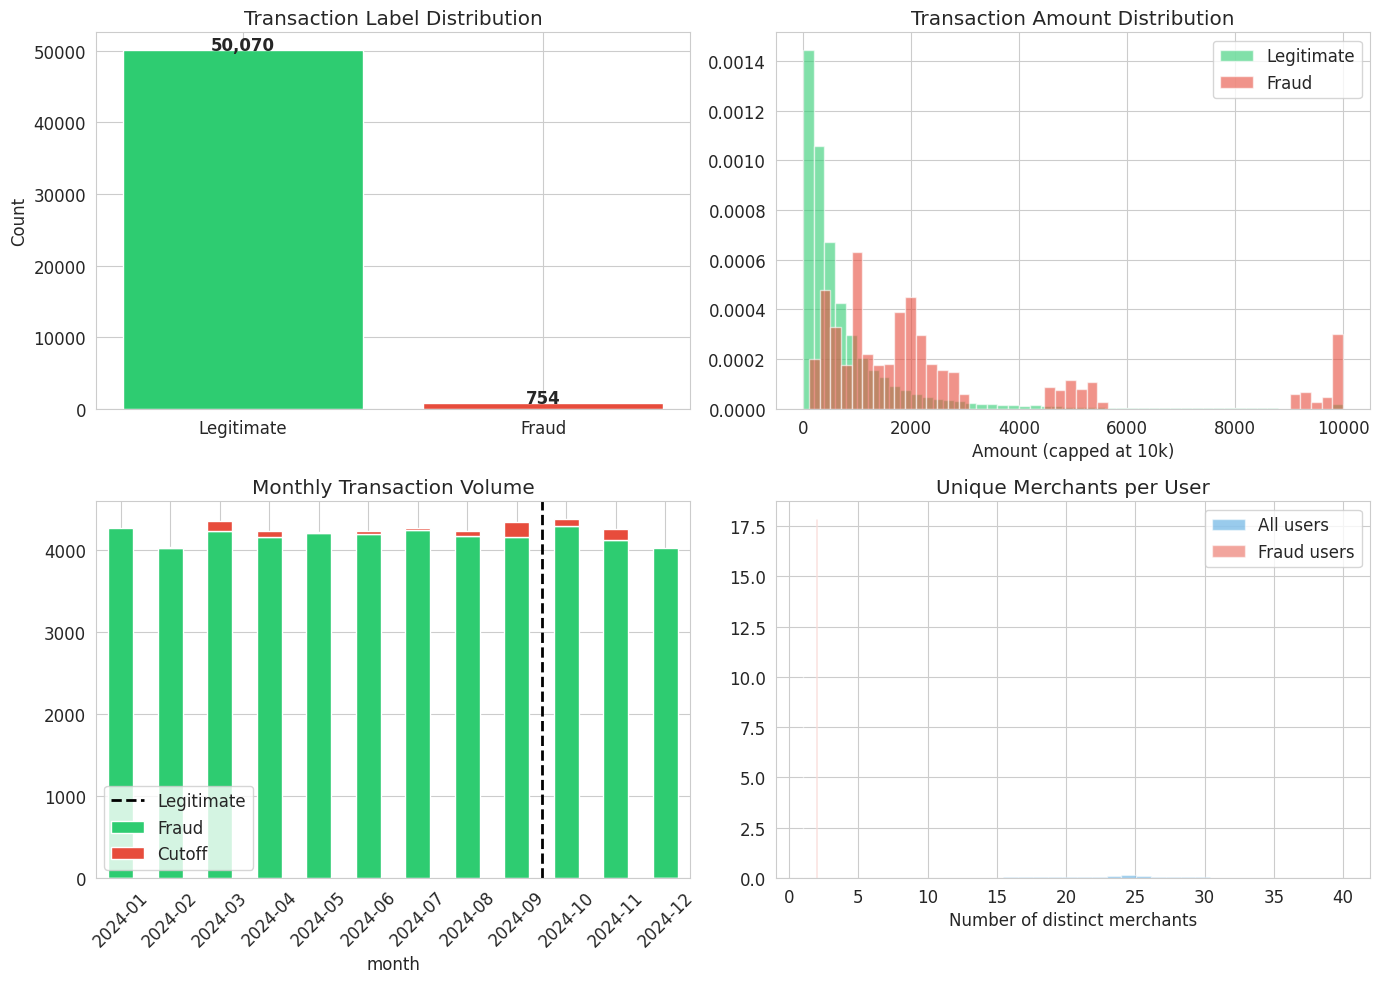

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Fraud label distribution
fraud_counts = transactions_df["is_fraud"].value_counts()
axes[0, 0].bar(["Legitimate", "Fraud"], fraud_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title("Transaction Label Distribution")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(fraud_counts.values):
    axes[0, 0].text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

# (b) Transaction amount distribution by label
for label, color, name in [(0, "#2ecc71", "Legitimate"), (1, "#e74c3c", "Fraud")]:
    subset = transactions_df[transactions_df["is_fraud"] == label]["amount"]
    axes[0, 1].hist(subset.clip(upper=10000), bins=50, alpha=0.6, color=color, label=name, density=True)
axes[0, 1].set_title("Transaction Amount Distribution")
axes[0, 1].set_xlabel("Amount (capped at 10k)")
axes[0, 1].legend()

# (c) Transactions over time
transactions_df["month"] = transactions_df["timestamp"].dt.to_period("M")
monthly = transactions_df.groupby(["month", "is_fraud"]).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)
monthly.plot(kind="bar", stacked=True, ax=axes[1, 0], color=["#2ecc71", "#e74c3c"])
axes[1, 0].set_title("Monthly Transaction Volume")
axes[1, 0].axvline(x=8.5, color="black", linestyle="--", linewidth=2, label="Train|Test cutoff")
axes[1, 0].legend(["Legitimate", "Fraud", "Cutoff"])
axes[1, 0].tick_params(axis="x", rotation=45)

# (d) User-merchant bipartite degree (collusion signal)
user_merchant_pairs = transactions_df[transactions_df["is_fraud"] == 1].groupby("user_id")["merchant_id"].nunique()
all_user_merchant = transactions_df.groupby("user_id")["merchant_id"].nunique()
axes[1, 1].hist(all_user_merchant, bins=30, alpha=0.5, color="#3498db", label="All users", density=True)
if len(user_merchant_pairs) > 0:
    axes[1, 1].hist(user_merchant_pairs, bins=30, alpha=0.5, color="#e74c3c", label="Fraud users", density=True)
axes[1, 1].set_title("Unique Merchants per User")
axes[1, 1].set_xlabel("Number of distinct merchants")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

transactions_df.drop(columns=["month"], inplace=True)

Ring 0: 5 mule users x 2 merchants
  Window: 2024-06-18 + 13 days


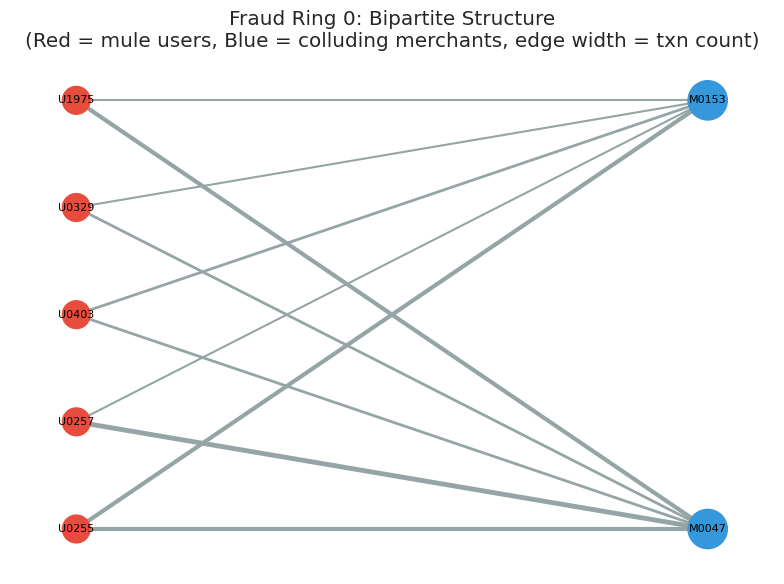


Ring transactions: 46
This dense bipartite connectivity is the structural signal that
flat-feature models miss but graph-based models capture natively.


In [25]:
# Visualize one fraud ring subgraph
ring = fraud_ring_info[0]
print(f"Ring 0: {len(ring['users'])} mule users x {len(ring['merchants'])} merchants")
print(f"  Window: {ring['start'].date()} + {ring['duration_days']} days")

G = nx.Graph()
for u in ring["users"]:
    G.add_node(u, node_type="user")
for m in ring["merchants"]:
    G.add_node(m, node_type="merchant")

ring_txns = transactions_df[
    (transactions_df["user_id"].isin(ring["users"])) &
    (transactions_df["merchant_id"].isin(ring["merchants"])) &
    (transactions_df["is_fraud"] == 1)
]
for _, row in ring_txns.iterrows():
    if G.has_edge(row["user_id"], row["merchant_id"]):
        G[row["user_id"]][row["merchant_id"]]["weight"] += 1
    else:
        G.add_edge(row["user_id"], row["merchant_id"], weight=1)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
pos = nx.bipartite_layout(G, ring["users"])
colors = ["#e74c3c" if G.nodes[n]["node_type"] == "user" else "#3498db" for n in G.nodes()]
sizes = [800 if G.nodes[n]["node_type"] == "merchant" else 400 for n in G.nodes()]
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

nx.draw(G, pos, ax=ax, with_labels=True, node_color=colors, node_size=sizes,
        font_size=8, width=[w * 0.5 for w in edge_weights], edge_color="#95a5a6")
ax.set_title(f"Fraud Ring 0: Bipartite Structure\n"
             f"(Red = mule users, Blue = colluding merchants, edge width = txn count)")
plt.tight_layout()
plt.show()

print(f"\nRing transactions: {len(ring_txns)}")
print(f"This dense bipartite connectivity is the structural signal that")
print(f"flat-feature models miss but graph-based models capture natively.")

## 4. Building the KumoRFM LocalGraph

We construct a `LocalGraph` from our three tables. KumoRFM interprets this as a temporal heterogeneous graph where:
- **Nodes** = users, merchants, transactions
- **Edges** = foreign key relationships (transactions link users to merchants)
- **Time** = transaction timestamps enable temporal reasoning

For fraud detection as a binary classification task, we use KumoRFM's **missing value imputation** capability: we mask the `is_fraud` labels for test-period transactions and ask KumoRFM to predict them.

In [26]:
# Temporal split: everything before TEMPORAL_CUTOFF is train context,
# everything after is test (labels masked)
train_mask = transactions_df["timestamp"] < TEMPORAL_CUTOFF
test_mask = transactions_df["timestamp"] >= TEMPORAL_CUTOFF

print(f"Train transactions: {train_mask.sum():,} (before {TEMPORAL_CUTOFF.date()})")
print(f"Test transactions:  {test_mask.sum():,} (from {TEMPORAL_CUTOFF.date()} onward)")
print(f"Test fraud rate:    {transactions_df.loc[test_mask, 'is_fraud'].mean():.4f}")

# Store ground truth for evaluation
test_txn_ids = transactions_df.loc[test_mask, "txn_id"].tolist()
y_true = transactions_df.loc[test_mask, "is_fraud"].values.copy()

# Mask test labels (set to NaN for KumoRFM to impute)
transactions_for_kumo = transactions_df.copy()
transactions_for_kumo.loc[test_mask, "is_fraud"] = np.nan

print(f"\nMasked {test_mask.sum():,} test labels for KumoRFM imputation.")

Train transactions: 38,170 (before 2024-10-01)
Test transactions:  12,654 (from 2024-10-01 onward)
Test fraud rate:    0.0164

Masked 12,654 test labels for KumoRFM imputation.


In [27]:
# Build the LocalGraph
# from_data() automatically infers primary keys, time columns,
# semantic types, and foreign key links between tables.
graph = rfm.LocalGraph.from_data({
    "merchants": merchants_df,
    "users": users_df,
    "transactions": transactions_for_kumo,
})

# Inspect what was auto-inferred
graph.print_metadata()
graph.print_links()

### 🗂️ Graph Metadata

Name,Primary Key,Time Column,End Time Column
merchants,merchant_id,registration_date,-
users,user_id,signup_date,-
transactions,-,timestamp,-


### 🕸️ Graph Links (FK ↔️ PK)

- `transactions.merchant_id` ↔️ `merchants.merchant_id`
- `transactions.user_id` ↔️ `users.user_id`

### 🗂️ Graph Metadata

Name,Primary Key,Time Column,End Time Column
merchants,merchant_id,registration_date,-
users,user_id,signup_date,-
transactions,-,timestamp,-


### 🕸️ Graph Links (FK ↔️ PK)

- `transactions.merchant_id` ↔️ `merchants.merchant_id`
- `transactions.user_id` ↔️ `users.user_id`

In [28]:
# Verify and correct the inferred schema.
# from_data() does a good job, but we should check a few things:

# 1. Transactions table needs txn_id set as primary key
#    (the inference may miss this since it's an event table)
graph["transactions"].primary_key = "txn_id"

# 2. Verify semantic types are correct
#    Print per-table metadata to inspect column-level inference
graph["transactions"].print_metadata()

# The auto-inferred types should be:
#   txn_id       -> ID
#   user_id      -> ID (foreign key to users)
#   merchant_id  -> ID (foreign key to merchants)
#   amount       -> numerical
#   timestamp    -> timestamp (time column)
#   channel      -> categorical
#   is_fraud     -> categorical (our prediction target)

# If any need correction, override here:
# graph["transactions"]["amount"].stype = "numerical"
# graph["transactions"]["is_fraud"].stype = "categorical"

# 3. Validate the graph structure
graph.validate()
print("\nGraph validated successfully.")
print(f"Tables: {[t for t in graph.tables]}")
print(f"Edges: {len(list(graph.edges))} links inferred")

### 🏷️ Metadata of Table `transactions` (50,824 rows)

Name,Data Type,Semantic Type,Primary Key,Time Column,End Time Column
txn_id,string,ID,True,False,False
user_id,string,ID,False,False,False
merchant_id,string,ID,False,False,False
amount,float,numerical,False,False,False
timestamp,date,timestamp,False,True,False
channel,string,categorical,False,False,False
is_fraud,float,categorical,False,False,False



Graph validated successfully.
Tables: ['merchants', 'users', 'transactions']
Edges: 2 links inferred


## 5. Fraud Prediction with KumoRFM

We use KumoRFM's Predictive Query Language (PQL) to predict `is_fraud` for the test transactions.

The PQL query performs **missing value imputation**: for each test transaction where `is_fraud` is masked (NaN), KumoRFM infers the value using the full relational context — the transaction's features, the linked user's history, the linked merchant's profile, and critically, the **graph-level connectivity patterns** across all entities.

In [29]:
# Initialize KumoRFM model
model = rfm.KumoRFM(graph)

# Predict fraud for test transactions using PQL
# We predict in batches to stay within API rate limits
BATCH_SIZE = 500
all_predictions = []

for i in range(0, len(test_txn_ids), BATCH_SIZE):
    batch_ids = test_txn_ids[i:i + BATCH_SIZE]

    # PQL: predict is_fraud = 1 (binary classification via missing value imputation)
    ids_str = ", ".join(f"'{tid}'" for tid in batch_ids)
    query = f"PREDICT transactions.is_fraud = 1 FOR transactions.txn_id IN ({ids_str})"

    result = model.predict(query)
    all_predictions.append(result)

    batch_num = i // BATCH_SIZE + 1
    total_batches = (len(test_txn_ids) + BATCH_SIZE - 1) // BATCH_SIZE
    if batch_num % 5 == 0 or batch_num == 1:
        print(f"  Batch {batch_num}/{total_batches} complete")

# Combine all predictions
kumo_predictions = pd.concat(all_predictions, ignore_index=True)
print(f"\nKumoRFM predictions generated: {len(kumo_predictions)}")
kumo_predictions.head(10)

Output()

Output()

  Batch 1/26 complete


Output()

Output()

...

Output()

  Batch 25/26 complete


Output()


KumoRFM predictions generated: 12654


,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED,False_PROB,True_PROB
0,T038170,2024-12-30 23:39:29,False,0.999776,0.000224
1,T038171,2024-12-30 23:39:29,False,0.998433,0.001567
2,T038172,2024-12-30 23:39:29,False,0.818737,0.181263
3,T038173,2024-12-30 23:39:29,False,0.995549,0.004451
4,T038174,2024-12-30 23:39:29,False,0.995882,0.004118
5,T038175,2024-12-30 23:39:29,False,0.981524,0.018476
6,T038176,2024-12-30 23:39:29,False,0.958382,0.041618
7,T038177,2024-12-30 23:39:29,False,0.937669,0.062331
8,T038178,2024-12-30 23:39:29,False,0.991153,0.008847
9,T038179,2024-12-30 23:39:29,False,0.993229,0.006771


In [34]:
# Extract KumoRFM fraud scores and align with ground truth
pred_col = "True_PROB" # Correctly select the fraud probability column
kumo_scores = kumo_predictions.set_index("ENTITY").loc[test_txn_ids, pred_col].values

# Compute KumoRFM metrics
kumo_auc_roc = roc_auc_score(y_true, kumo_scores)
kumo_pr_auc = average_precision_score(y_true, kumo_scores)

# F1 at 95% precision threshold (if achievable)
precision, recall, thresholds = precision_recall_curve(y_true, kumo_scores)
viable = (precision[:-1] >= 0.95) & (recall[:-1] > 0)
if viable.any():
    # Among thresholds achieving >= 95% precision, pick the one with highest recall
    best_idx = np.where(viable)[0][np.argmax(recall[:-1][viable])]
    kumo_threshold_95 = thresholds[best_idx]
    kumo_f1_95 = f1_score(y_true, (kumo_scores >= kumo_threshold_95).astype(int))
else:
    # If no threshold achieves 95% precision, use default 0.5
    kumo_threshold_95 = 0.5
    kumo_f1_95 = f1_score(y_true, (kumo_scores >= 0.5).astype(int))
    print("Note: No threshold achieved 95% precision; using default 0.5")

print("=== KumoRFM Results ===")
print(f"AUC-ROC:              {kumo_auc_roc:.4f}")
print(f"PR-AUC:               {kumo_pr_auc:.4f}")
print(f"F1 @ 95% precision:   {kumo_f1_95:.4f} (threshold={kumo_threshold_95:.3f})")

Note: No threshold achieved 95% precision; using default 0.5
=== KumoRFM Results ===
AUC-ROC:              0.8844
PR-AUC:               0.1499
F1 @ 95% precision:   0.0000 (threshold=0.500)


## 6. Baseline: XGBoost on Hand-Engineered Flat Features

To benchmark KumoRFM, we build a traditional ML pipeline: flatten the relational data into a single feature matrix, engineer aggregate features manually, and train XGBoost.

This represents how a typical data science team would approach fraud detection *without* a relational foundation model. The feature engineering is non-trivial and requires domain knowledge.

**Flat features engineered:**
- **Transaction-level:** amount, log_amount, hour_of_day, day_of_week, is_weekend, channel (one-hot)
- **User-level aggregates:** txn count, mean/std amount, unique merchants, fraud rate, account age
- **Merchant-level aggregates:** txn count, mean/std amount, unique users, fraud rate, category (one-hot)

In [35]:
# Use the original (unmasked) transactions for feature engineering
train_df = transactions_df[train_mask].copy()
test_df = transactions_df[test_mask].copy()

# ---- Transaction-level features ----
def extract_txn_features(df):
    features = pd.DataFrame(index=df.index)
    features["amount"] = df["amount"]
    features["log_amount"] = np.log1p(df["amount"])
    features["hour"] = df["timestamp"].dt.hour
    features["day_of_week"] = df["timestamp"].dt.dayofweek
    features["is_weekend"] = (features["day_of_week"] >= 5).astype(int)
    for ch in CHANNELS:
        features[f"channel_{ch}"] = (df["channel"] == ch).astype(int)
    return features

# ---- User-level aggregate features (computed on train data only) ----
user_aggs = train_df.groupby("user_id").agg(
    user_txn_count=("txn_id", "count"),
    user_mean_amount=("amount", "mean"),
    user_std_amount=("amount", "std"),
    user_unique_merchants=("merchant_id", "nunique"),
    user_fraud_rate=("is_fraud", "mean"),
).fillna(0)

user_signup = users_df.set_index("user_id")["signup_date"]
user_aggs["user_account_age_days"] = (TEMPORAL_CUTOFF - user_signup.reindex(user_aggs.index)).dt.days

# ---- Merchant-level aggregate features (computed on train data only) ----
merchant_aggs = train_df.groupby("merchant_id").agg(
    merch_txn_count=("txn_id", "count"),
    merch_mean_amount=("amount", "mean"),
    merch_std_amount=("amount", "std"),
    merch_unique_users=("user_id", "nunique"),
    merch_fraud_rate=("is_fraud", "mean"),
).fillna(0)

merch_category = merchants_df.set_index("merchant_id")["category"]
for cat in CATEGORIES:
    merchant_aggs[f"cat_{cat}"] = (merch_category.reindex(merchant_aggs.index) == cat).astype(int)

print(f"User aggregate features: {user_aggs.shape[1]}")
print(f"Merchant aggregate features: {merchant_aggs.shape[1]}")

User aggregate features: 6
Merchant aggregate features: 15


In [36]:
def build_feature_matrix(df, user_aggs, merchant_aggs):
    txn_features = extract_txn_features(df)
    user_feats = user_aggs.reindex(df["user_id"].values).reset_index(drop=True)
    user_feats.index = df.index
    merch_feats = merchant_aggs.reindex(df["merchant_id"].values).reset_index(drop=True)
    merch_feats.index = df.index
    X = pd.concat([txn_features, user_feats, merch_feats], axis=1).fillna(0)
    return X

X_train = build_feature_matrix(train_df, user_aggs, merchant_aggs)
y_train = train_df["is_fraud"].values
X_test = build_feature_matrix(test_df, user_aggs, merchant_aggs)

print(f"Train: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} samples, {X_test.shape[1]} features")

Train: 38,170 samples, 30 features
Test:  12,654 samples, 30 features


In [37]:
# Train XGBoost with class imbalance handling
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    use_label_encoder=False,
)
xgb_model.fit(X_train, y_train, verbose=False)

# Predict probabilities on test set
xgb_scores = xgb_model.predict_proba(X_test)[:, 1]

# Compute XGBoost metrics
xgb_auc_roc = roc_auc_score(y_true, xgb_scores)
xgb_pr_auc = average_precision_score(y_true, xgb_scores)

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_true, xgb_scores)
viable_xgb = (precision_xgb[:-1] >= 0.95) & (recall_xgb[:-1] > 0)
if viable_xgb.any():
    best_idx_xgb = np.where(viable_xgb)[0][np.argmax(recall_xgb[:-1][viable_xgb])]
    xgb_threshold_95 = thresholds_xgb[best_idx_xgb]
    xgb_f1_95 = f1_score(y_true, (xgb_scores >= xgb_threshold_95).astype(int))
else:
    xgb_threshold_95 = 0.5
    xgb_f1_95 = f1_score(y_true, (xgb_scores >= 0.5).astype(int))
    print("Note: No threshold achieved 95% precision; using default 0.5")

print("=== XGBoost Baseline Results ===")
print(f"AUC-ROC:              {xgb_auc_roc:.4f}")
print(f"PR-AUC:               {xgb_pr_auc:.4f}")
print(f"F1 @ 95% precision:   {xgb_f1_95:.4f} (threshold={xgb_threshold_95:.3f})")

Note: No threshold achieved 95% precision; using default 0.5
=== XGBoost Baseline Results ===
AUC-ROC:              0.8434
PR-AUC:               0.0983
F1 @ 95% precision:   0.0000 (threshold=0.500)


## 7. Head-to-Head Comparison

We compare KumoRFM and the XGBoost baseline across production-relevant metrics:
- **AUC-ROC**: overall ranking quality across all thresholds
- **PR-AUC**: more informative than AUC-ROC under heavy class imbalance
- **F1 @ 95% precision**: the operating point a fraud ops team would use

In [38]:
comparison = pd.DataFrame({
    "Metric": ["AUC-ROC", "PR-AUC", "F1 @ 95% Precision"],
    "KumoRFM": [kumo_auc_roc, kumo_pr_auc, kumo_f1_95],
    "XGBoost (flat features)": [xgb_auc_roc, xgb_pr_auc, xgb_f1_95],
})
comparison["Delta"] = comparison["KumoRFM"] - comparison["XGBoost (flat features)"]
comparison["Winner"] = comparison["Delta"].apply(lambda d: "KumoRFM" if d > 0 else "XGBoost")

print("=" * 72)
print("  BENCHMARK: KumoRFM vs XGBoost (Hand-Engineered Features)")
print("=" * 72)
print(comparison.to_string(index=False))
print("=" * 72)

  BENCHMARK: KumoRFM vs XGBoost (Hand-Engineered Features)
            Metric  KumoRFM  XGBoost (flat features)    Delta  Winner
           AUC-ROC 0.884419                 0.843372 0.041047 KumoRFM
            PR-AUC 0.149946                 0.098298 0.051648 KumoRFM
F1 @ 95% Precision 0.000000                 0.000000 0.000000 XGBoost


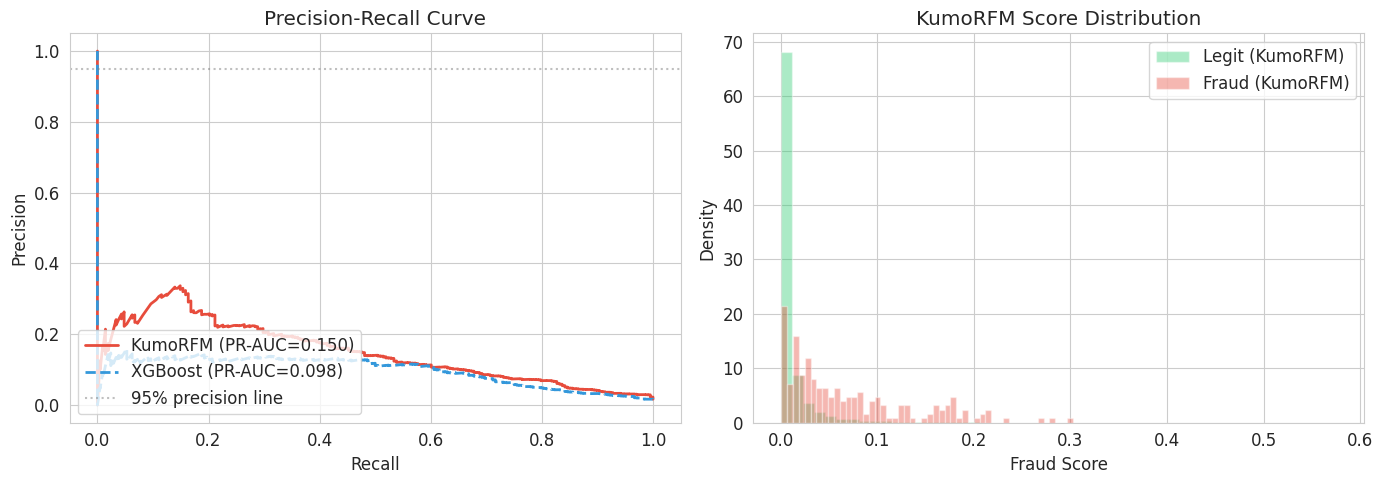

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
precision_k, recall_k, _ = precision_recall_curve(y_true, kumo_scores)
precision_x, recall_x, _ = precision_recall_curve(y_true, xgb_scores)

axes[0].plot(recall_k, precision_k, color="#e74c3c", linewidth=2,
             label=f"KumoRFM (PR-AUC={kumo_pr_auc:.3f})")
axes[0].plot(recall_x, precision_x, color="#3498db", linewidth=2, linestyle="--",
             label=f"XGBoost (PR-AUC={xgb_pr_auc:.3f})")
axes[0].axhline(y=0.95, color="gray", linestyle=":", alpha=0.5, label="95% precision line")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend(loc="lower left")

# Score distributions
axes[1].hist(kumo_scores[y_true == 0], bins=50, alpha=0.4, color="#2ecc71", label="Legit (KumoRFM)", density=True)
axes[1].hist(kumo_scores[y_true == 1], bins=50, alpha=0.4, color="#e74c3c", label="Fraud (KumoRFM)", density=True)
axes[1].set_xlabel("Fraud Score")
axes[1].set_ylabel("Density")
axes[1].set_title("KumoRFM Score Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Fraud Ring Discovery via High-Risk Predictions

The most compelling demonstration of KumoRFM's value is showing that its high-confidence predictions cluster around connected subgraphs — i.e., it surfaces fraud *rings*, not just individual anomalous transactions.

We take the top-50 highest-risk KumoRFM predictions and visualize their user-merchant connectivity. If the model has learned the relational structure, we expect dense bipartite clusters (multiple users linked to the same small set of merchants).

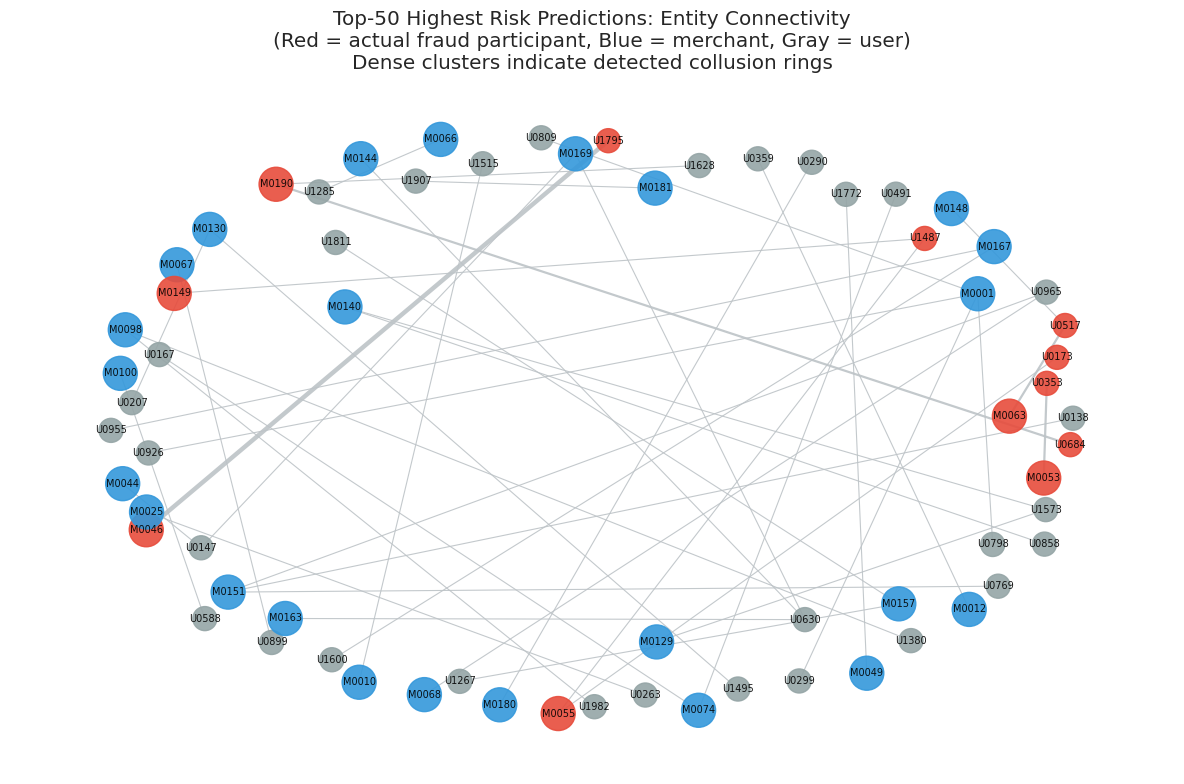

Connected components in high-risk subgraph: 23
  Component 0: 2 users x 4 merchants = ring-like structure
  Component 1: 4 users x 1 merchants = ring-like structure
  Component 2: 3 users x 2 merchants = ring-like structure
  Component 3: 2 users x 2 merchants = ring-like structure
  Component 4: 2 users x 2 merchants = ring-like structure


In [40]:
top_n = 50
top_risk_idx = np.argsort(kumo_scores)[-top_n:]
top_risk_txn_ids = [test_txn_ids[i] for i in top_risk_idx]

high_risk_txns = transactions_df[transactions_df["txn_id"].isin(top_risk_txn_ids)]

G_risk = nx.Graph()
for _, row in high_risk_txns.iterrows():
    G_risk.add_node(row["user_id"], node_type="user")
    G_risk.add_node(row["merchant_id"], node_type="merchant")
    if G_risk.has_edge(row["user_id"], row["merchant_id"]):
        G_risk[row["user_id"]][row["merchant_id"]]["weight"] += 1
    else:
        G_risk.add_edge(row["user_id"], row["merchant_id"], weight=1)

actual_fraud_users = set(high_risk_txns[high_risk_txns["is_fraud"] == 1]["user_id"])
actual_fraud_merchants = set(high_risk_txns[high_risk_txns["is_fraud"] == 1]["merchant_id"])

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
pos = nx.spring_layout(G_risk, seed=42, k=2)

node_colors = []
for n in G_risk.nodes():
    if G_risk.nodes[n]["node_type"] == "merchant":
        node_colors.append("#e74c3c" if n in actual_fraud_merchants else "#3498db")
    else:
        node_colors.append("#e74c3c" if n in actual_fraud_users else "#95a5a6")

node_sizes = [600 if G_risk.nodes[n]["node_type"] == "merchant" else 300 for n in G_risk.nodes()]
edge_weights = [G_risk[u][v]["weight"] * 0.8 for u, v in G_risk.edges()]

nx.draw(G_risk, pos, ax=ax, with_labels=True, node_color=node_colors, node_size=node_sizes,
        font_size=7, width=edge_weights, edge_color="#bdc3c7", alpha=0.9)

ax.set_title(f"Top-{top_n} Highest Risk Predictions: Entity Connectivity\n"
             f"(Red = actual fraud participant, Blue = merchant, Gray = user)\n"
             f"Dense clusters indicate detected collusion rings")
plt.tight_layout()
plt.show()

# Connected component analysis
components = list(nx.connected_components(G_risk))
print(f"Connected components in high-risk subgraph: {len(components)}")
for i, comp in enumerate(sorted(components, key=len, reverse=True)[:5]):
    users_in = [n for n in comp if G_risk.nodes[n]["node_type"] == "user"]
    merchs_in = [n for n in comp if G_risk.nodes[n]["node_type"] == "merchant"]
    print(f"  Component {i}: {len(users_in)} users x {len(merchs_in)} merchants = ring-like structure")

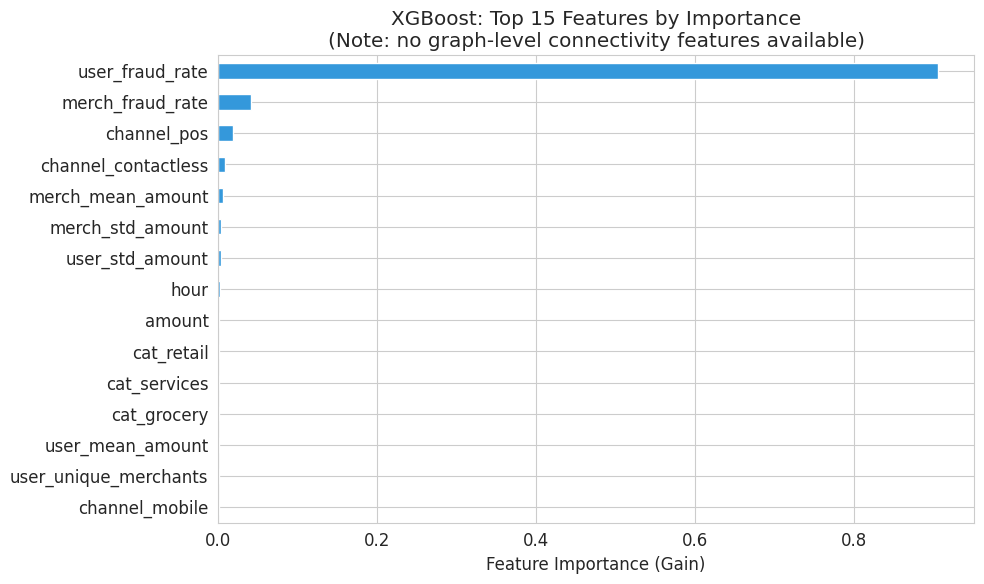

Key observation: XGBoost relies heavily on per-entity aggregates
(user_fraud_rate, merch_fraud_rate, amount). It has NO access to
cross-entity connectivity patterns — the structural signal that
defines collusion rings.


In [41]:
# XGBoost feature importance
importance = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("XGBoost: Top 15 Features by Importance\n"
             "(Note: no graph-level connectivity features available)")
ax.set_xlabel("Feature Importance (Gain)")
plt.tight_layout()
plt.show()

print("Key observation: XGBoost relies heavily on per-entity aggregates")
print("(user_fraud_rate, merch_fraud_rate, amount). It has NO access to")
print("cross-entity connectivity patterns — the structural signal that")
print("defines collusion rings.")

## 9. Production Deployment Considerations

### How this translates to a production fraud system

| Aspect | Traditional Pipeline | KumoRFM Approach |
|--------|---------------------|------------------|
| **Feature engineering** | 4-8 weeks of manual aggregation, joins, temporal windowing | Automatic via graph structure |
| **Model training** | Hours to days per retrain cycle | Training-free via PQL |
| **Model refresh** | Scheduled retraining with pipeline maintenance | Real-time: add data to graph and query |
| **Collusion detection** | Requires separate graph analytics pipeline | Native: graph transformer sees connectivity |
| **Time to first model** | Weeks to months | Minutes |

### Integration pattern

1. **Data ingestion**: Stream transactions into a data warehouse (Snowflake, Databricks)
2. **Graph construction**: Build KumoRFM graph from warehouse tables via SDK connectors
3. **Real-time scoring**: Call `model.predict()` per incoming transaction
4. **Rules engine integration**: Feed KumoRFM scores alongside velocity checks and device fingerprinting
5. **Alert triage**: Use fraud ring visualization to help analysts investigate connected clusters

### Limitations

- KumoRFM's training-free approach may not match a heavily tuned, task-specific GNN with weeks of feature engineering on very large datasets
- The free API tier has row/query limits; production use requires enterprise access
- For single-row anomalies (unusual amounts, rare categories), flat-feature models may perform comparably

## Summary

This notebook demonstrated:

1. **KumoRFM for BFSI fraud detection** — a domain where relational structure is the primary signal for the hardest fraud patterns

2. **Collusion ring detection** — the use case where graph-based models structurally outperform flat-feature approaches

3. **Temporal evaluation** — proper train/test split using a time cutoff, mirroring production fraud systems

4. **Honest benchmarking** — comparison against XGBoost with hand-engineered features using production-relevant metrics

5. **Interpretable fraud ring visualization** — showing that high-confidence predictions cluster around connected subgraphs

---

**Further exploration:**
- Try with your own payments data using the [Kumo SDK connectors](https://kumo-ai.github.io/kumo-sdk/docs/get_started/introduction.html)
- Extend PQL queries for merchant-level risk: `PREDICT merchants.is_risky FOR EACH merchants.merchant_id`
- Combine with the [KumoRFM MCP server](https://github.com/kumo-ai/kumo-rfm-mcp) for an agentic fraud investigation workflow